### Cargar Red

In [ ]:
import pypsa
n = #RED

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.05_1H_demand.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


### Capacidad Instalada de Almacenamiento

In [2]:
import pandas as pd

# --- PHS (StorageUnit) ---
phs = n.storage_units[n.storage_units.carrier.str.lower() == "phs"].copy()
phs["p_MW"] = phs["p_nom_opt"].fillna(phs["p_nom"])
phs["e_MWh"] = phs["p_MW"] * phs["max_hours"]
phs_tbl = phs[["bus", "carrier", "p_MW", "e_MWh"]].copy()

# --- Batteries (StorageUnit) ---
bat = n.storage_units[n.storage_units.carrier.str.lower() == "battery"].copy()
bat["p_MW"] = bat["p_nom_opt"].fillna(bat["p_nom"])
bat["e_MWh"] = bat["p_MW"] * bat["max_hours"]
bat_tbl = bat[["bus", "carrier", "p_MW", "e_MWh"]].copy()

# --- Hydrogen Links (define mappings first) ---
h2_fc = n.links[n.links.carrier == "H2 fuel cell"].copy()
h2_fc["p_MW"] = h2_fc["p_nom_opt"].fillna(h2_fc["p_nom"])
h2bus_to_acbus = h2_fc.set_index("bus0")["bus1"]
p_by_h2bus = h2_fc.groupby("bus0")["p_MW"].sum()

# --- Hydrogen Stores ---
h2_buses = n.buses.index[n.buses.index.str.endswith(" H2")]

h2 = n.stores[n.stores.bus.isin(h2_buses)].copy()
h2["e_MWh"] = h2["e_nom_opt"].fillna(h2["e_nom"])

h2_tbl = h2[["bus", "carrier", "e_MWh"]].copy()
h2_tbl["p_MW"] = h2_tbl["bus"].map(p_by_h2bus)
h2_tbl["bus"] = h2_tbl["bus"].map(h2bus_to_acbus)


# --- Single output table ---
out = pd.concat([phs_tbl, bat_tbl, h2_tbl], ignore_index=True)
out = out[["bus", "carrier", "p_MW", "e_MWh"]].sort_values(["bus", "carrier"])

# Format output with no decimals
out["p_MW"] = out["p_MW"].round(0)
out["e_MWh"] = out["e_MWh"].round(0)

# Filter out rows where either p_MW or e_MWh is zero or NaN
out = out[(out["p_MW"] > 0) & (out["e_MWh"] > 0)].copy()

# Convert to int after filtering
out["p_MW"] = out["p_MW"].astype(int)
out["e_MWh"] = out["e_MWh"].astype(int)

# Reset index and hide it in display
out.reset_index(drop=True, inplace=True)
out.style.hide(axis='index')

bus,carrier,p_MW,e_MWh
AR.CEN,PHS,750,13500
AR.CUY,PHS,224,4032
AR.CUY,battery,9921,39684
AR.NOA,battery,11523,46091
AR.PAT,H2_cavern,275,366111
AR.PAT,battery,104,416


### Potencia vs estado de carga

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.05_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units


Using e_nom_opt (optimized capacity) for stores


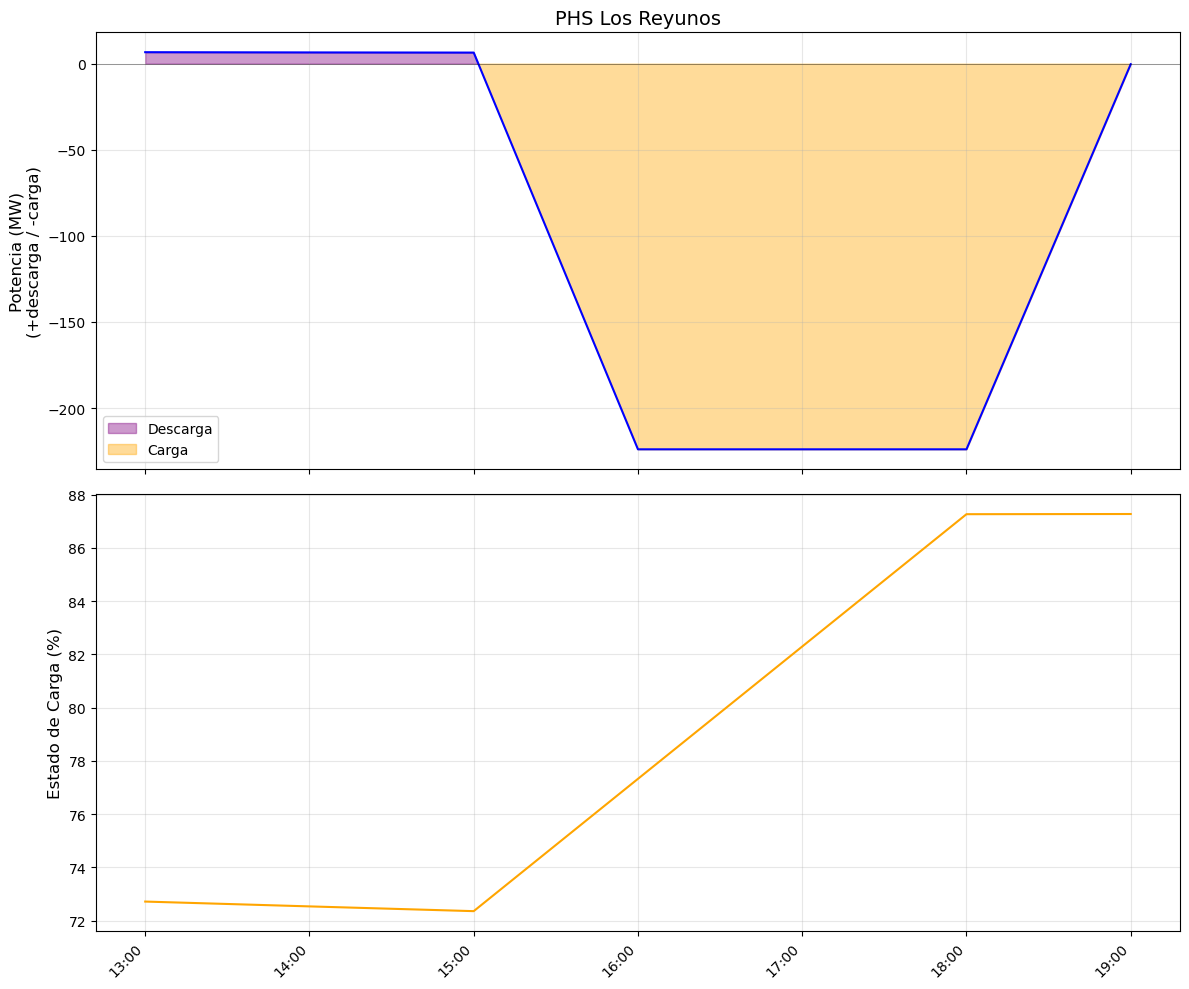


Phs Storage Statistics at Bus AR.CUY (2013-03-01 to 2013-03-01):

Power (Generation/Discharge):
  Mean: -93.24 MW
  Max Discharge: 6.67 MW at 2013-03-01 13:00:00
  Max Charge: 224.00 MW at 2013-03-01 17:00:00

State of Charge:
  Mean: 78.8%
  Max: 87.3% at 2013-03-01 19:00:00
  Min: 72.4% at 2013-03-01 15:00:00
  Total Energy Capacity: 4032.00 MWh

Available storage carriers at Bus AR.CUY: ['PHS']

Composition:
  Storage Units: 1
  Stores: 0

Buses included in this analysis:
  AR.CUY: 1 unit(s)

Phs Storage Units from CSV at Bus AR.CUY:
--------------------------------------------------------------------------------
    ID           Name  Capacity (MW)
LREYHB H. DIAMANTE SA            224

Total Power Capacity from CSV: 224.00 MW



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as mticker
import pypsa
n = #RED

# Choose the buses you want to analyze (or [""] for whole system)
bus_names = ["AR.CUY"]  # List of buses, or [""] for system-wide
# Example: bus_names = ["AR.COM", "AR.GBA"] or bus_names = [""]

# Choose the storage carriers you want to plot
carrier_names = ["PHS"]  # List of storage carriers
# Storage carriers: "hydro" (reservoir), "PHS", "battery", etc.

# Option: Auto-include related battery buses (e.g., "AR.CUY battery" when searching "AR.CUY")
include_battery_buses = True

# Choose time window
start = pd.Timestamp("2013-03-01 13:00:00")
end   = pd.Timestamp("2013-03-01 19:00:00")

# --- Minimum y-axis range threshold (MW and %) ---
min_power_range = 1.0  # MW - If power range is smaller than this, use this as minimum
min_soc_range = 1.0    # % - If SoC range is smaller than this, use this as minimum

# --- Load powerplants data from both files ---
powerplants_original_path = powerplants.csv"
powerplants_bus_path = powerplants_to_elec_s_9_bus.csv"

# Load both files (read-only)
powerplants_original = pd.read_csv(powerplants_original_path)
powerplants_bus = pd.read_csv(powerplants_bus_path)

# --- Carrier to CSV mapping ---
carrier_to_csv_mapping = {
    'PHS': ('hydro', 'Pumped Storage'),
    'hydro': ('hydro', 'Reservoir'),
    'battery': ('battery', None),
}

# =============================================================================
# COMBINED DATA EXTRACTION (storage_units + stores)
# =============================================================================

# --- Get storage_units data ---
p_storage_units = n.storage_units_t.p  # snapshots x storage_units (MW, positive = discharge)
soc_storage_units = n.storage_units_t.state_of_charge  # snapshots x storage_units (MWh)
carriers_storage_units = n.storage_units["carrier"]
buses_storage_units = n.storage_units["bus"]
max_hours_storage_units = n.storage_units["max_hours"]

# Use p_nom_opt if available (optimized capacity), otherwise p_nom
if "p_nom_opt" in n.storage_units.columns:
    p_nom_storage_units = n.storage_units["p_nom_opt"]
else:
    p_nom_storage_units = n.storage_units["p_nom"]

energy_capacity_storage_units = p_nom_storage_units * max_hours_storage_units

# --- Get stores data ---
p_stores = n.stores_t.p  # snapshots x stores (MW, positive = discharge)
soc_stores = n.stores_t.e  # snapshots x stores (MWh) - state of charge
carriers_stores = n.stores["carrier"]
buses_stores = n.stores["bus"]

# CRITICAL FIX: Use e_nom_opt for optimized capacity, not e_nom
if "e_nom_opt" in n.stores.columns:
    e_nom_stores = n.stores["e_nom_opt"]  # Energy capacity after optimization (MWh)
    print("Using e_nom_opt (optimized capacity) for stores")
else:
    e_nom_stores = n.stores["e_nom"]
    print("Using e_nom (initial capacity) for stores")

# --- Combine storage_units and stores ---
# Add suffix to distinguish sources
p_storage_units_renamed = p_storage_units.add_suffix('_su')
p_stores_renamed = p_stores.add_suffix('_st')
soc_storage_units_renamed = soc_storage_units.add_suffix('_su')
soc_stores_renamed = soc_stores.add_suffix('_st')

# Combine power and SoC DataFrames
p_combined = pd.concat([p_storage_units_renamed, p_stores_renamed], axis=1)
soc_combined = pd.concat([soc_storage_units_renamed, soc_stores_renamed], axis=1)

# Combine metadata Series with appropriate suffixes
carriers_combined = pd.concat([
    carriers_storage_units.add_suffix('_su'),
    carriers_stores.add_suffix('_st')
])
buses_combined = pd.concat([
    buses_storage_units.add_suffix('_su'),
    buses_stores.add_suffix('_st')
])
energy_capacity_combined = pd.concat([
    energy_capacity_storage_units.add_suffix('_su'),
    e_nom_stores.add_suffix('_st')
])

# --- Exclude load shedding ---
non_load_shedding = carriers_combined != "load shedding"
p_filtered_all = p_combined.loc[:, non_load_shedding]
soc_filtered_all = soc_combined.loc[:, non_load_shedding]
carriers_filtered_all = carriers_combined[non_load_shedding]
buses_filtered_all = buses_combined[non_load_shedding]
energy_capacity_filtered_all = energy_capacity_combined[non_load_shedding]

# =============================================================================
# HELPER FUNCTION: Find related buses
# =============================================================================

def get_related_buses(base_bus, all_buses, include_battery_suffix=True, include_h2_suffix=True):
    related = [base_bus]

    if include_battery_suffix:
        b = f"{base_bus} battery"
        if b in all_buses:
            related.append(b)

    if include_h2_suffix:
        h = f"{base_bus} H2"
        if h in all_buses:
            related.append(h)

    return related


# =============================================================================
# LOOP THROUGH BUS-CARRIER COMBINATIONS
# =============================================================================

for bus_name in bus_names:
    for carrier_name in carrier_names:
        
        # Reset filters for each combination
        p_filtered = p_filtered_all.copy()
        soc_filtered = soc_filtered_all.copy()
        carriers_filtered = carriers_filtered_all.copy()
        buses_filtered = buses_filtered_all.copy()
        energy_capacity_filtered = energy_capacity_filtered_all.copy()
        
        # --- Filter by bus if specified ---
        if bus_name != "":
            # Get all related buses
            all_buses_in_network = buses_filtered.unique()
            related_buses = get_related_buses(bus_name, all_buses_in_network, include_battery_buses)
            
            # Create mask for any of the related buses
            bus_mask = buses_filtered.isin(related_buses)
            
            p_filtered = p_filtered.loc[:, bus_mask]
            soc_filtered = soc_filtered.loc[:, bus_mask]
            carriers_filtered = carriers_filtered[bus_mask]
            buses_used = buses_filtered[bus_mask]
            energy_capacity_filtered = energy_capacity_filtered[bus_mask]
            
            # Create location label
            if len(related_buses) > 1:
                location_label = f"at Bus {bus_name} (including related buses: {', '.join(related_buses)})"
            else:
                location_label = f"at Bus {bus_name}"
        else:
            buses_used = buses_filtered
            location_label = "System-wide"
        
        # --- Sum generation and SoC by carrier for each timestep ---
        generation_by_carrier = pd.DataFrame()
        soc_by_carrier = pd.DataFrame()
        capacity_by_carrier = {}
        
        for carrier in carriers_filtered.unique():
            carrier_mask = carriers_filtered == carrier
            generation_by_carrier[carrier] = p_filtered.loc[:, carrier_mask].sum(axis=1)
            soc_by_carrier[carrier] = soc_filtered.loc[:, carrier_mask].sum(axis=1)
            capacity_by_carrier[carrier] = energy_capacity_filtered[carrier_mask].sum()
        
        # --- Check if carrier exists in the filtered data ---
        if carrier_name not in generation_by_carrier.columns:
            print(f"\n{'='*80}")
            print(f"Storage carrier '{carrier_name}' not found {location_label}.")
            print(f"Available storage carriers {location_label}: {sorted(generation_by_carrier.columns)}")
            print(f"{'='*80}\n")
            continue
        
        # --- Extract data for the selected carrier ---
        carrier_generation = generation_by_carrier[carrier_name]
        carrier_soc = soc_by_carrier[carrier_name]
        carrier_capacity = capacity_by_carrier[carrier_name]
        
        # --- Handle zero capacity (optimization didn't build any storage) ---
        if carrier_capacity == 0:
            print(f"\n{'='*80}")
            print(f"WARNING: {carrier_name.capitalize()} storage capacity is 0 MWh {location_label}.")
            print(f"The optimizer did not build any {carrier_name} storage at this location.")
            print(f"{'='*80}\n")
            continue
        
        # --- Calculate SoC as percentage ---
        carrier_soc_pct = 100 * carrier_soc / carrier_capacity
        
        # --- Filter by time window ---
        carrier_generation_filtered = carrier_generation.loc[start:end]
        carrier_soc_pct_filtered = carrier_soc_pct.loc[start:end]
        
        # --- Find max/min for generation ---
        max_generation = carrier_generation_filtered.max()
        max_generation_time = carrier_generation_filtered.idxmax()
        min_generation = carrier_generation_filtered.min()
        min_generation_time = carrier_generation_filtered.idxmin()
        
        # --- Find max/min for SoC ---
        max_soc = carrier_soc_pct_filtered.max()
        max_soc_time = carrier_soc_pct_filtered.idxmax()
        min_soc = carrier_soc_pct_filtered.min()
        min_soc_time = carrier_soc_pct_filtered.idxmin()
        
        # --- Create two subplots vertically ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
        
        # --- PLOT 1: Generation (positive = discharge, negative = charge) ---
        ax1.plot(carrier_generation_filtered.index, carrier_generation_filtered.values, 
                linewidth=1.5, color='blue')
        ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

        # Fill charging (negative) in orange, discharging (positive) in purple
        ax1.fill_between(carrier_generation_filtered.index, carrier_generation_filtered.values, 0,
                        where=(carrier_generation_filtered.values >= 0),
                        color='purple', alpha=0.4, label='Descarga', interpolate=True)
        ax1.fill_between(carrier_generation_filtered.index, carrier_generation_filtered.values, 0,
                        where=(carrier_generation_filtered.values < 0),
                        color='orange', alpha=0.4, label='Carga', interpolate=True)

        # Format y-axis
        ax1.ticklabel_format(axis='y', style='plain', useOffset=False)
        ax1.yaxis.get_major_formatter().set_scientific(False)
        ax1.yaxis.get_major_formatter().set_useOffset(False)

        # Set minimum range to avoid wiggling
        power_range = max_generation - min_generation
        if power_range < min_power_range:
            center = (max_generation + min_generation) / 2
            ax1.set_ylim(center - min_power_range/2, center + min_power_range/2)

        ax1.set_ylabel('Potencia (MW)\n(+descarga / -carga)', fontsize=12)
        ax1.set_title(f'PHS Los Reyunos', fontsize=14)
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='lower left')
        
        # --- PLOT 2: State of Charge (%) ---
        ax2.plot(carrier_soc_pct_filtered.index, carrier_soc_pct_filtered.values,
                linewidth=1.5, color='orange')

        # Format y-axis
        ax2.ticklabel_format(axis='y', style='plain', useOffset=False)
        ax2.yaxis.get_major_formatter().set_scientific(False)
        ax2.yaxis.get_major_formatter().set_useOffset(False)

        # Set minimum range to avoid wiggling
        soc_range = max_soc - min_soc
        if soc_range < min_soc_range:
            center = (max_soc + min_soc) / 2
            ax2.set_ylim(center - min_soc_range/2, center + min_soc_range/2)
        
        # Set minimum range to avoid wiggling
        soc_range = max_soc - min_soc
        if soc_range < min_soc_range:
            center = (max_soc + min_soc) / 2
            ax2.set_ylim(center - min_soc_range/2, center + min_soc_range/2)
        
        # Format x-axis
        ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
        ax2.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=1))
        plt.xticks(rotation=45, ha='right')

        ax2.set_ylabel('Estado de Carga (%)', fontsize=12)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # =============================================================================
        # PRINT SUMMARY STATISTICS
        # =============================================================================
        
        print(f"\n{'='*80}")
        print(f"{carrier_name.capitalize()} Storage Statistics {location_label} ({start.date()} to {end.date()}):")
        print(f"\nPower (Generation/Discharge):")
        print(f"  Mean: {carrier_generation_filtered.mean():.2f} MW")
        print(f"  Max Discharge: {max_generation:.2f} MW at {max_generation_time}")
        print(f"  Max Charge: {abs(min_generation):.2f} MW at {min_generation_time}")
        
        print(f"\nState of Charge:")
        print(f"  Mean: {carrier_soc_pct_filtered.mean():.1f}%")
        print(f"  Max: {max_soc:.1f}% at {max_soc_time}")
        print(f"  Min: {min_soc:.1f}% at {min_soc_time}")
        print(f"  Total Energy Capacity: {carrier_capacity:.2f} MWh")
        
        # Print available carriers
        print(f"\nAvailable storage carriers {location_label}: {sorted(generation_by_carrier.columns)}")
        
        # =============================================================================
        # LIST INDIVIDUAL STORAGE UNITS/STORES
        # =============================================================================
        
        # Count storage_units vs stores
        carrier_mask = carriers_filtered == carrier_name
        units_in_carrier = carriers_filtered[carrier_mask]
        
        n_storage_units = sum(1 for name in units_in_carrier.index if name.endswith('_su'))
        n_stores = sum(1 for name in units_in_carrier.index if name.endswith('_st'))
        
        print(f"\nComposition:")
        print(f"  Storage Units: {n_storage_units}")
        print(f"  Stores: {n_stores}")
        
        # Show which buses contributed
        if bus_name != "":
            buses_contributing = buses_used[carrier_mask].unique()
            if len(buses_contributing) > 0:
                print(f"\nBuses included in this analysis:")
                for bus in buses_contributing:
                    count = sum(buses_used[carrier_mask] == bus)
                    print(f"  {bus}: {count} unit(s)")
        
        # --- List storage units involved from CSV ---
        if bus_name != "" and bus_name in buses_contributing:
            # Get the CSV mapping for the selected carrier
            if carrier_name in carrier_to_csv_mapping:
                fueltype, technology = carrier_to_csv_mapping[carrier_name]
                
                # Get plants at the selected bus from bus mapping file
                plants_at_bus = powerplants_bus[powerplants_bus['bus'] == bus_name]
                
                # Merge with original to get Fueltype and Technology info
                plants_merged = plants_at_bus.merge(
                    powerplants_original[['id', 'Name', 'Fueltype', 'Technology']],
                    left_on=['ID', 'Name'],
                    right_on=['id', 'Name'],
                    how='inner'
                )
                
                # Filter by fueltype
                mask = plants_merged['Fueltype'] == fueltype
                
                # Add technology filter if specified
                if technology is not None:
                    mask = mask & (plants_merged['Technology'] == technology)
                
                relevant_plants = plants_merged[mask]
                
                if len(relevant_plants) > 0:
                    print(f"\n{carrier_name.capitalize()} Storage Units from CSV at Bus {bus_name}:")
                    print("-" * 80)
                    display_df = relevant_plants[['ID', 'Name', 'Capacity']].copy()
                    display_df.columns = ['ID', 'Name', 'Capacity (MW)']
                    print(display_df.to_string(index=False))
                    print(f"\nTotal Power Capacity from CSV: {display_df['Capacity (MW)'].sum():.2f} MW")
            else:
                print(f"\nCarrier '{carrier_name}' not mapped to CSV columns yet.")
        
        print(f"{'='*80}\n")

### Generacion y Almacenamiento

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


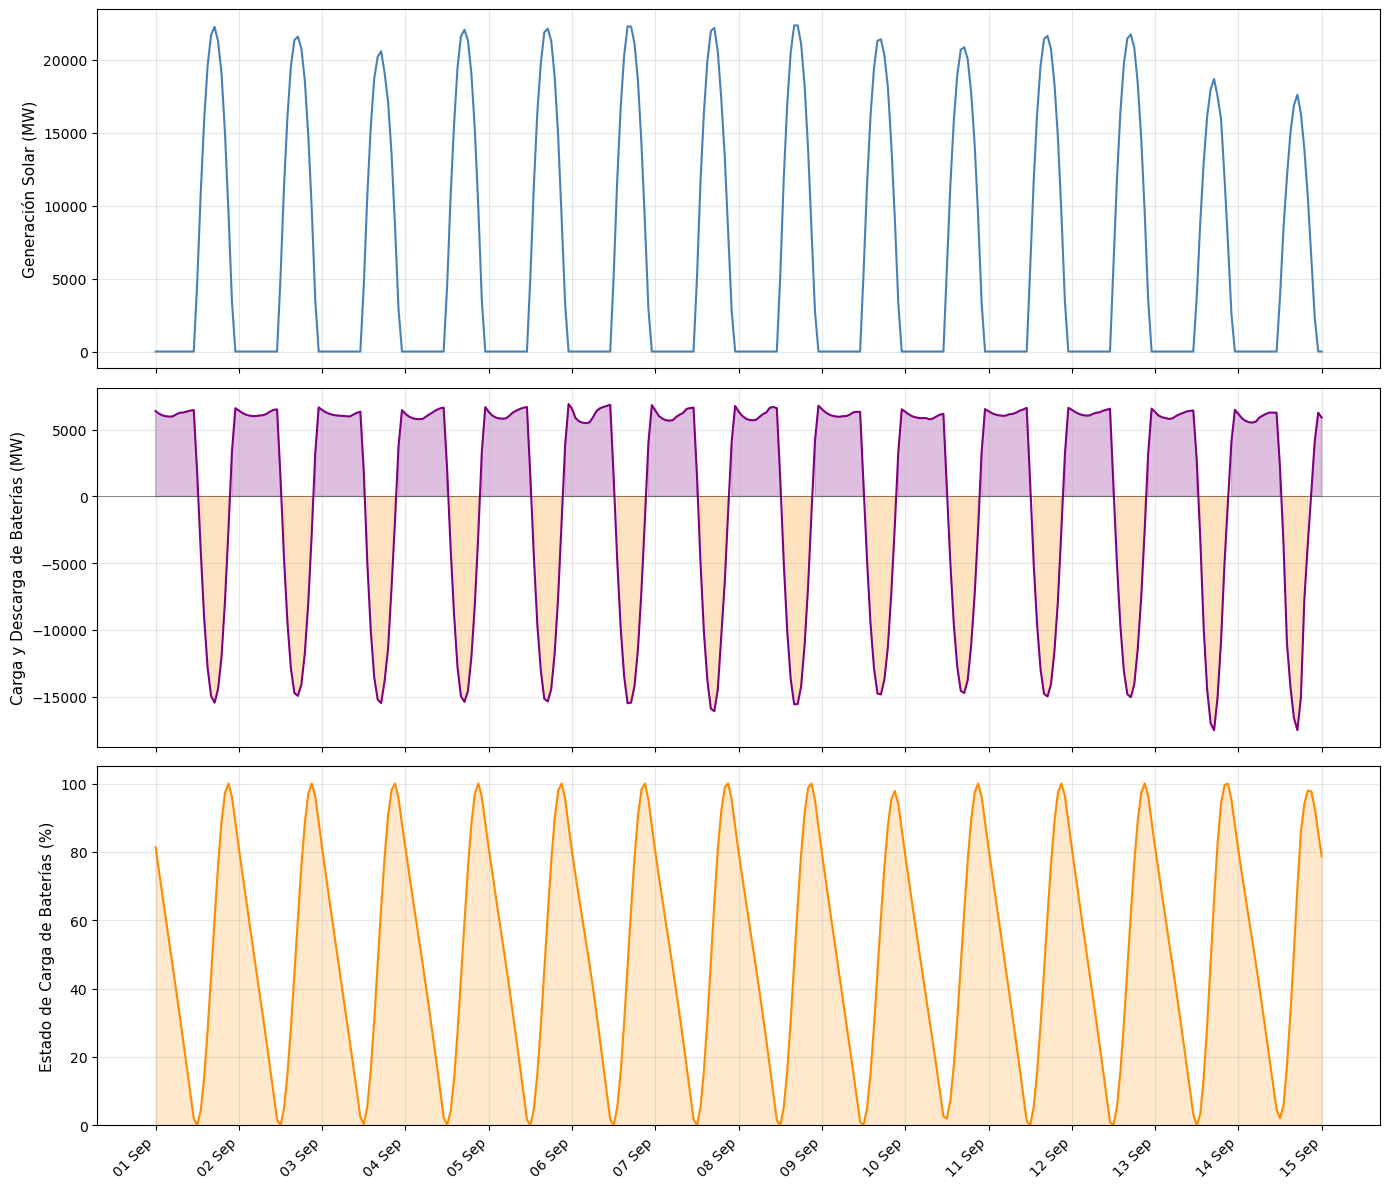

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

# =============================================================================
# USER CONFIGURATION
# =============================================================================

network_path = #RED

bus_name          = "AR.NOA"    # A single bus name, or "" for system-wide
generator_carrier = "solar"     # e.g. "solar", "onwind", "CCGT", "hydro", "nuclear", ...
storage_carrier   = "battery"   # e.g. "battery", "PHS", "hydro", ...

start = pd.Timestamp("2013-09-01 00:00:00")
end   = pd.Timestamp("2013-09-15 00:00:00")

# =============================================================================
# LOAD NETWORK
# =============================================================================

n = pypsa.Network(network_path)

# =============================================================================
# GENERATORS
# =============================================================================

p_gen     = n.generators_t.p
carr_gen  = n.generators["carrier"]
buses_gen = n.generators["bus"]

if bus_name != "":
    bus_mask  = buses_gen == bus_name
    p_gen     = p_gen.loc[:, bus_mask]
    carr_gen  = carr_gen[bus_mask]

gen_by_carrier = pd.DataFrame(index=n.snapshots)
for c in carr_gen.unique():
    gen_by_carrier[c] = p_gen.loc[:, carr_gen == c].sum(axis=1)

carrier_gen_ts = gen_by_carrier.get(generator_carrier, pd.Series(dtype=float)).loc[start:end]

# =============================================================================
# STORAGE UNITS
# =============================================================================

p_su    = n.storage_units_t.p
soc_su  = n.storage_units_t.state_of_charge
carr_su = n.storage_units["carrier"]
bus_su  = n.storage_units["bus"]
p_nom   = n.storage_units.get("p_nom_opt", n.storage_units["p_nom"])
ecap_su = p_nom * n.storage_units["max_hours"]

if bus_name != "":
    # Include both "<bus>" and "<bus> battery" buses
    related_buses = [bus_name, f"{bus_name} battery"]
    bus_mask = bus_su.isin(related_buses)
    p_su    = p_su.loc[:, bus_mask]
    soc_su  = soc_su.loc[:, bus_mask]
    carr_su = carr_su[bus_mask]
    ecap_su = ecap_su[bus_mask]

stor_p_by_carrier   = pd.DataFrame(index=n.snapshots)
stor_soc_by_carrier = pd.DataFrame(index=n.snapshots)
ecap_by_carrier     = {}

for c in carr_su.unique():
    cmask = carr_su == c
    stor_p_by_carrier[c]   = p_su.loc[:, cmask].sum(axis=1)
    stor_soc_by_carrier[c] = soc_su.loc[:, cmask].sum(axis=1)
    ecap_by_carrier[c]     = ecap_su[cmask].sum()

carrier_p_ts   = stor_p_by_carrier.get(storage_carrier,   pd.Series(dtype=float)).loc[start:end]
carrier_soc_ts = stor_soc_by_carrier.get(storage_carrier, pd.Series(dtype=float)).loc[start:end]
total_ecap     = ecap_by_carrier.get(storage_carrier, 0)

carrier_soc_pct = (100 * carrier_soc_ts / total_ecap) if total_ecap > 0 else carrier_soc_ts * 0

# =============================================================================
# PLOT
# =============================================================================

location_label = f"Bus {bus_name}" if bus_name != "" else "System-wide"

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ── Panel 1: Generator output ──────────────────────────────────────────────
if not carrier_gen_ts.empty:
    ax1.plot(carrier_gen_ts.index, carrier_gen_ts.values, linewidth=1.5, color="steelblue")
else:
    ax1.text(0.5, 0.5, f"No data for '{generator_carrier}'",
             transform=ax1.transAxes, ha="center")

ax1.set_ylabel("Generación Solar (MW)", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(axis="y", style="plain", useOffset=False)

# ── Panel 2: Storage charge / discharge ────────────────────────────────────
if not carrier_p_ts.empty:
    ax2.plot(carrier_p_ts.index, carrier_p_ts.values, linewidth=1.5, color="purple")
    ax2.axhline(0, color="black", linewidth=0.6, alpha=0.5)
    ax2.fill_between(carrier_p_ts.index, carrier_p_ts.values, 0,
                     where=carrier_p_ts.values >= 0,
                     alpha=0.25, color="purple", label="Discharge")
    ax2.fill_between(carrier_p_ts.index, carrier_p_ts.values, 0,
                     where=carrier_p_ts.values < 0,
                     alpha=0.25, color="darkorange", label="Charge")
else:
    ax2.text(0.5, 0.5, f"No data for '{storage_carrier}'",
             transform=ax2.transAxes, ha="center")

ax2.set_ylabel("Carga y Descarga de Baterías (MW)", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(axis="y", style="plain", useOffset=False)

# ── Panel 3: State of Charge ────────────────────────────────────────────────
if not carrier_soc_pct.empty and total_ecap > 0:
    ax3.plot(carrier_soc_pct.index, carrier_soc_pct.values, linewidth=1.5, color="darkorange")
    ax3.fill_between(carrier_soc_pct.index, carrier_soc_pct.values, alpha=0.2, color="darkorange")
    ax3.set_ylim(0, 105)
else:
    ax3.text(0.5, 0.5, f"No SoC data for '{storage_carrier}' (capacity = 0)",
             transform=ax3.transAxes, ha="center")

ax3.set_ylabel("Estado de Carga de Baterías (%)", fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.ticklabel_format(axis="y", style="plain", useOffset=False)

# ── Shared x-axis formatting ────────────────────────────────────────────────
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
ax3.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Generacion y almacenamiento 2

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


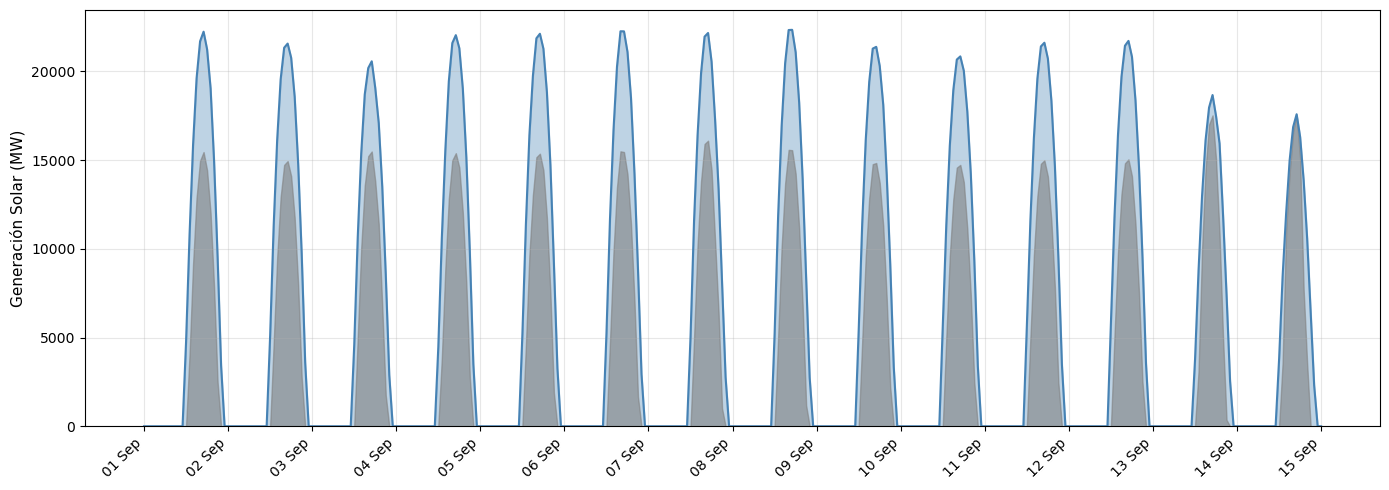

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

# =============================================================================
# USER CONFIGURATION
# =============================================================================

network_path = #RED

bus_name          = "AR.NOA"    # A single bus name, or "" for system-wide
generator_carrier = "solar"     # e.g. "solar", "onwind", "CCGT", "hydro", "nuclear", ...
storage_carrier   = "battery"   # e.g. "battery", "PHS", "hydro", ...

start = pd.Timestamp("2013-09-01 00:00:00")
end   = pd.Timestamp("2013-09-15 00:00:00")

# =============================================================================
# LOAD NETWORK
# =============================================================================

n = pypsa.Network(network_path)

# =============================================================================
# GENERATORS
# =============================================================================

p_gen     = n.generators_t.p
carr_gen  = n.generators["carrier"]
buses_gen = n.generators["bus"]

if bus_name != "":
    bus_mask = buses_gen == bus_name
    p_gen    = p_gen.loc[:, bus_mask]
    carr_gen = carr_gen[bus_mask]

gen_by_carrier = pd.DataFrame(index=n.snapshots)
for c in carr_gen.unique():
    gen_by_carrier[c] = p_gen.loc[:, carr_gen == c].sum(axis=1)

carrier_gen_ts = gen_by_carrier.get(generator_carrier, pd.Series(dtype=float)).loc[start:end]

# =============================================================================
# STORAGE UNITS  (charge power only)
# =============================================================================

p_su    = n.storage_units_t.p
carr_su = n.storage_units["carrier"]
bus_su  = n.storage_units["bus"]

if bus_name != "":
    related_buses = [bus_name, f"{bus_name} battery"]
    bus_mask = bus_su.isin(related_buses)
    p_su    = p_su.loc[:, bus_mask]
    carr_su = carr_su[bus_mask]

stor_p_by_carrier = pd.DataFrame(index=n.snapshots)
for c in carr_su.unique():
    cmask = carr_su == c
    stor_p_by_carrier[c] = p_su.loc[:, cmask].sum(axis=1)

# Charging power: negative values in PyPSA → take abs, zero out discharge
raw_storage_p = stor_p_by_carrier.get(storage_carrier, pd.Series(0.0, index=n.snapshots)).loc[start:end]
charge_ts = raw_storage_p.clip(upper=0).abs()  # MW going into battery, always >= 0

charge_from_gen = charge_ts

# =============================================================================
# PLOT
# =============================================================================

location_label = f"Bus {bus_name}" if bus_name != "" else "System-wide"

fig, ax = plt.subplots(figsize=(14, 5))

if not carrier_gen_ts.empty:
    idx = carrier_gen_ts.index

    # Blue fill: total generation
    ax.fill_between(idx, carrier_gen_ts.values, 0,
                    alpha=0.35, color="steelblue", label=f"{generator_carrier.capitalize()} generation")
    ax.plot(idx, carrier_gen_ts.values, linewidth=1.5, color="steelblue")

    # Grey fill: portion going to battery charge (stacked from 0)
    ax.fill_between(idx, charge_from_gen.values, 0,
                    alpha=0.6, color="grey", label=f"To {storage_carrier} charge")

else:
    ax.text(0.5, 0.5, f"No data for '{generator_carrier}'",
            transform=ax.transAxes, ha="center")

ax.set_ylabel("Generación Solar (MW)", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
ax.ticklabel_format(axis="y", style="plain", useOffset=False)

ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()